## Linl del dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

In [ ]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning & Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Configuración visual para que los gráficos resalten con estilo corporativo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

Visualización de las primeras 5 filas:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


C:\Users\Yefry\AppData\Local\Temp\ipykernel_4084\514648661.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sano (0)', 'Enfermo (1)'])
C:\Users\Yefry\AppData\Local\Temp\ipykernel_4084\514648661.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Sano (0)', 'Enfermo (1)'])


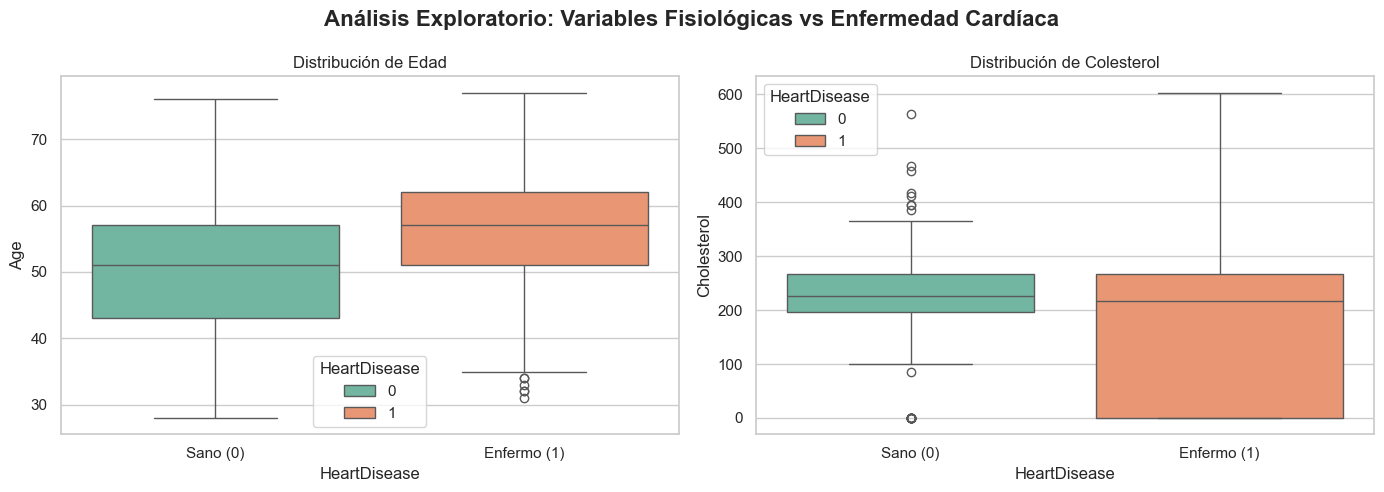

In [ ]:
# ==============================================================================
# 2. CARGA DE DATOS Y ANÁLISIS EXPLORATORIO (EDA)
# ==============================================================================
df = pd.read_csv('heart.csv')

print("Visualización de las primeras 5 filas:")
display(df.head())

# Gráficos de distribución (Edad y Colesterol frente a la enfermedad)+
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis Exploratorio: Variables Fisiológicas vs Enfermedad Cardíaca', fontsize=16, fontweight='bold')

sns.boxplot(ax=axes[0], x='HeartDisease', y='Age', data=df, hue='HeartDisease', palette='Set2')
axes[0].set_title('Distribución de Edad')
axes[0].set_xticklabels(['Sano (0)', 'Enfermo (1)'])

sns.boxplot(ax=axes[1], x='HeartDisease', y='Cholesterol', data=df, hue='HeartDisease', palette='Set2')
axes[1].set_title('Distribución de Colesterol')
axes[1].set_xticklabels(['Sano (0)', 'Enfermo (1)'])

plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# 3. PRUEBAS ESTADÍSTICAS (Validación de Hipótesis)
# ==============================================================================
# Aplicamos el test de Mann-Whitney U para comprobar si la diferencia 
# de edades entre pacientes sanos y enfermos es estadísticamente significativa.

edad_sanos = df[df['HeartDisease'] == 0]['Age']
edad_enfermos = df[df['HeartDisease'] == 1]['Age']

estadistico, p_value = stats.mannwhitneyu(edad_sanos, edad_enfermos)

print("--- Test de Mann-Whitney U para la variable 'Edad' ---")
print(f"P-value obtenido: {p_value:.10f}")

if p_value < 0.05:
    print("Conclusión: Rechazamos la hipótesis nula. La diferencia de edades entre ambos grupos ES estadísticamente significativa.")
else:
    print("Conclusión: No podemos rechazar la hipótesis nula. La diferencia NO es estadísticamente significativa.")

--- Test de Mann-Whitney U para la variable 'Edad' ---
P-value obtenido: 0.0000000000
Conclusión: Rechazamos la hipótesis nula. La diferencia de edades entre ambos grupos ES estadísticamente significativa.


In [7]:
# ==============================================================================
# 4. PREPROCESAMIENTO DE DATOS Y PCA
# ==============================================================================
df_procesado = df.copy()

# Codificación de variables categóricas (texto a números)
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
encoder = LabelEncoder()
for col in cat_cols:
    df_procesado[col] = encoder.fit_transform(df_procesado[col])

# Separar variables predictoras (X) de la variable objetivo (y)
X = df_procesado.drop('HeartDisease', axis=1)
y = df_procesado['HeartDisease']

# Escalado de datos (Estandarización)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicación de PCA (Análisis de Componentes Principales)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
varianza_explicada = sum(pca.explained_variance_ratio_)

print(f"Preprocesamiento completado. Varianza explicada por las 2 componentes principales del PCA: {varianza_explicada:.2%}")

Preprocesamiento completado. Varianza explicada por las 2 componentes principales del PCA: 38.45%


In [2]:
# ==============================================================================
# 5. FUNCIÓN DE EVALUACIÓN VISUAL AVANZADA
# ==============================================================================
def graficar_matriz_profesional(y_true, y_pred, nombre_modelo):
    cm = confusion_matrix(y_true, y_pred)
    
    nombres = [
        'Verdadero Negativo\n(Sano -> Sano)', 
        'Falso Positivo\n(Sano -> Enfermo)', 
        'Falso Negativo\n¡PELIGRO CRÍTICO!\n(Enfermo -> Sano)', 
        'Verdadero Positivo\n(Enfermo -> Enfermo)'
    ]
    
    conteos = ["{0:0.0f}".format(valor) for valor in cm.flatten()]
    porcentajes = ["{0:.1%}".format(valor) for valor in cm.flatten() / np.sum(cm)]
    etiquetas = [f"{n}\n{c}\n({p})" for n, c, p in zip(nombres, conteos, porcentajes)]
    etiquetas = np.asarray(etiquetas).reshape(2,2)
    
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(cm, annot=etiquetas, fmt='', cmap='Blues', cbar=False,
                     linewidths=2, linecolor='white', annot_kws={"size": 11, "weight": "bold"},
                     xticklabels=['Predice: Sano', 'Predice: Enfermo'], 
                     yticklabels=['Real: Sano', 'Real: Enfermo'])
    
    plt.title(f'Evaluación del Modelo: {nombre_modelo}', fontsize=15, pad=20, fontweight='bold')
    plt.yticks(rotation=0) 
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- Reporte de Clasificación: {nombre_modelo} ---")
    print(classification_report(y_true, y_pred))
    print("=" * 60 + "\n")

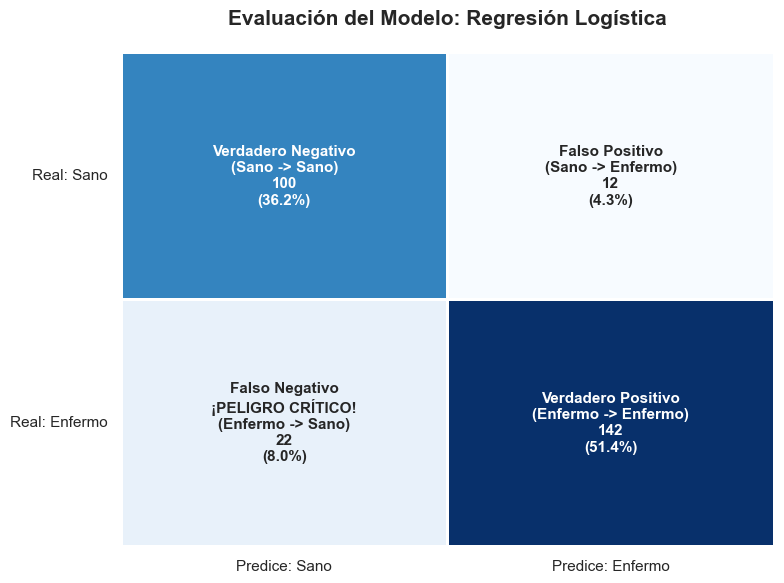


--- Reporte de Clasificación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       112
           1       0.92      0.87      0.89       164

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.87       276
weighted avg       0.88      0.88      0.88       276




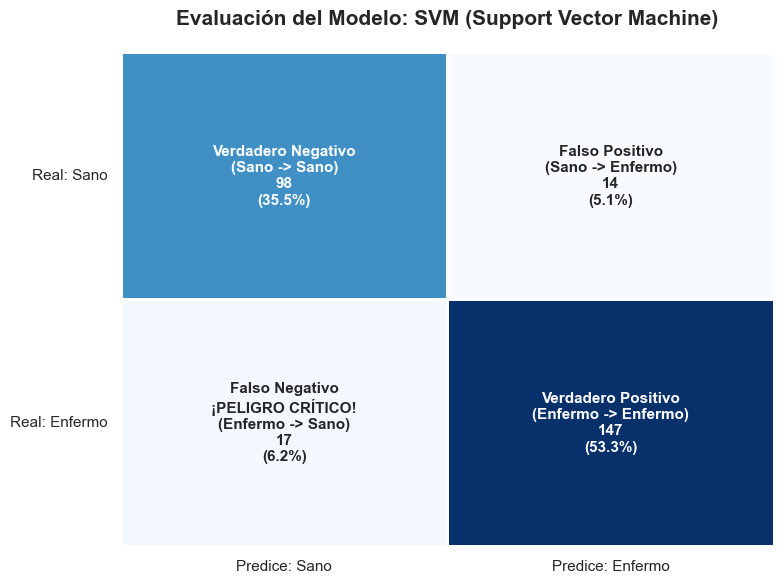


--- Reporte de Clasificación: SVM (Support Vector Machine) ---
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       112
           1       0.91      0.90      0.90       164

    accuracy                           0.89       276
   macro avg       0.88      0.89      0.88       276
weighted avg       0.89      0.89      0.89       276




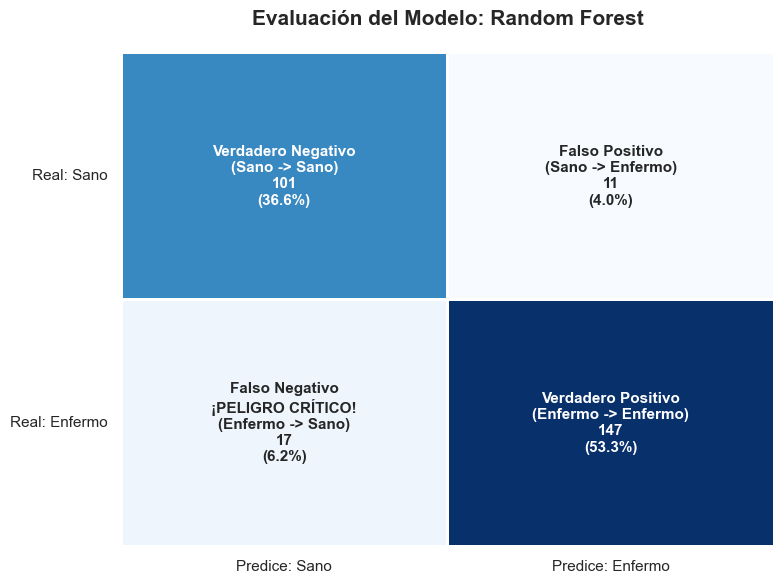


--- Reporte de Clasificación: Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       112
           1       0.93      0.90      0.91       164

    accuracy                           0.90       276
   macro avg       0.89      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276




In [9]:
# ==============================================================================
# 6. MODELADO Y EVALUACIÓN COMPARATIVA
# ==============================================================================
# División en conjunto de entrenamiento y prueba (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Instanciamos los modelos
modelos = {
    "Regresión Logística": LogisticRegression(),
    "SVM (Support Vector Machine)": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Diccionario para guardar los modelos entrenados (lo usaremos en la celda 7)
modelos_entrenados = {}

# Entrenamiento y evaluación iterativa
for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo
    
    # Predicción
    y_pred = modelo.predict(X_test)
    
    # Visualización de resultados
    graficar_matriz_profesional(y_test, y_pred, nombre)

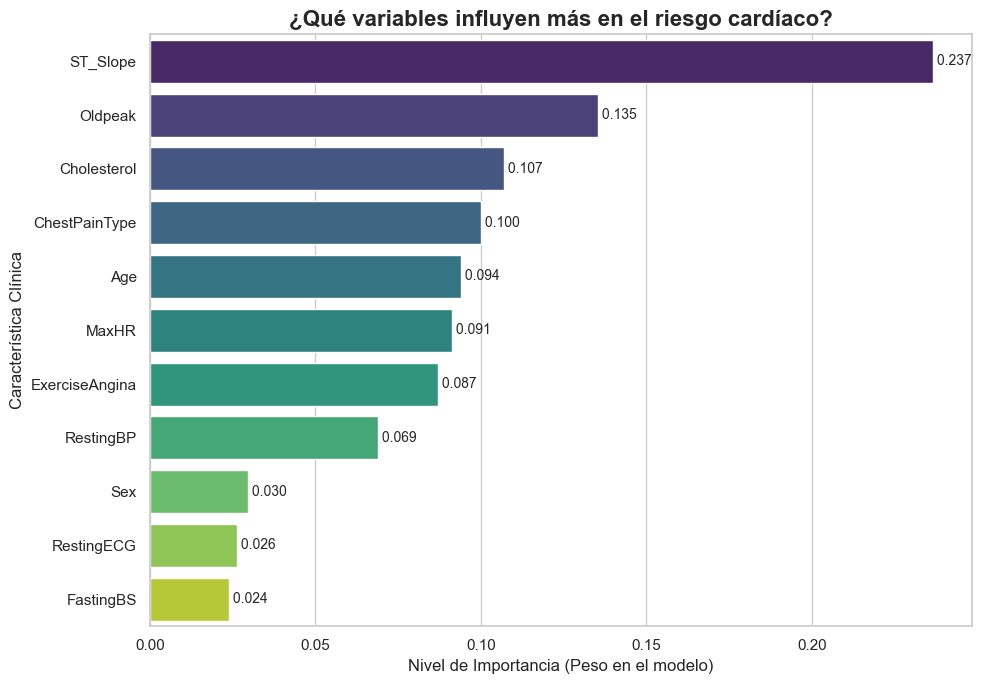

Interpretación: Las variables en la parte superior del gráfico son los principales indicadores que el modelo utiliza para determinar si un paciente está en riesgo de padecer una enfermedad cardíaca.


In [ ]:
# ==============================================================================
# 7. IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCE)
# ==============================================================================
# Extraemos el modelo Random Forest ya que tiene la propiedad feature_importances_
modelo_rf = modelos_entrenados["Random Forest"]-
importancias = modelo_rf.feature_importances_

# Creamos un DataFrame para visualizarlo mejor
df_importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Gráfico de barras horizontales
plt.figure(figsize=(10, 7))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, hue='Variable', palette='viridis', dodge=False, legend=False)

plt.title('¿Qué variables influyen más en el riesgo cardíaco?', fontsize=16, fontweight='bold')
plt.xlabel('Nivel de Importancia (Peso en el modelo)', fontsize=12)
plt.ylabel('Característica Clínica', fontsize=12)

# Añadimos los valores al final de cada barra para mayor precisión
for index, value in enumerate(df_importancias['Importancia']):
    plt.text(value, index, f' {value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Interpretación: Las variables en la parte superior del gráfico son los principales indicadores que el modelo utiliza para determinar si un paciente está en riesgo de padecer una enfermedad cardíaca.")